# Vergleich: Helligkeit und Kontrast


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, mannwhitneyu, spearmanr


In [2]:
DATA_DIR =  Path('../../data')
INPUT_CSV = DATA_DIR / '04_analysis_results' / 'visual_features' / '01_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_brightness_contrast.csv'
print(f'Reading {INPUT_CSV}')
df = pd.read_csv(INPUT_CSV)
print(df[['influencer_type', 'brightness_index', 'contrast_index']].groupby('influencer_type').agg(['count', 'mean', 'std']))

Reading ../../data/04_analysis_results/visual_features/01_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_brightness_contrast.csv                brightness_index                        contrast_index  \                           count        mean        std          count   influencer_type                                                          ai                           250  114.907464  34.688726            250   real                         250  120.949318  22.684990            250                                                                mean        std  influencer_type                        ai               59.556350  11.374979  real             60.026557   7.223060  

In [ ]:
FRAME_ROOT = DATA_DIR / '02_media/stratified_sample/frames'

def get_video_id(row):
    return str(row.get('id') or row.get('video_id'))

def first_frame_path(video_id: str):
    folder = FRAME_ROOT / video_id
    if not folder.is_dir():
        return None
    frames = sorted(folder.glob('*.jpeg'))
    if not frames:
        frames = sorted(folder.glob('*.jpg'))
    if not frames:
        return None
    return frames[len(frames)//2]

def load_image(path):
    import cv2
    img = cv2.imread(str(path))
    if img is None:
        return None
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


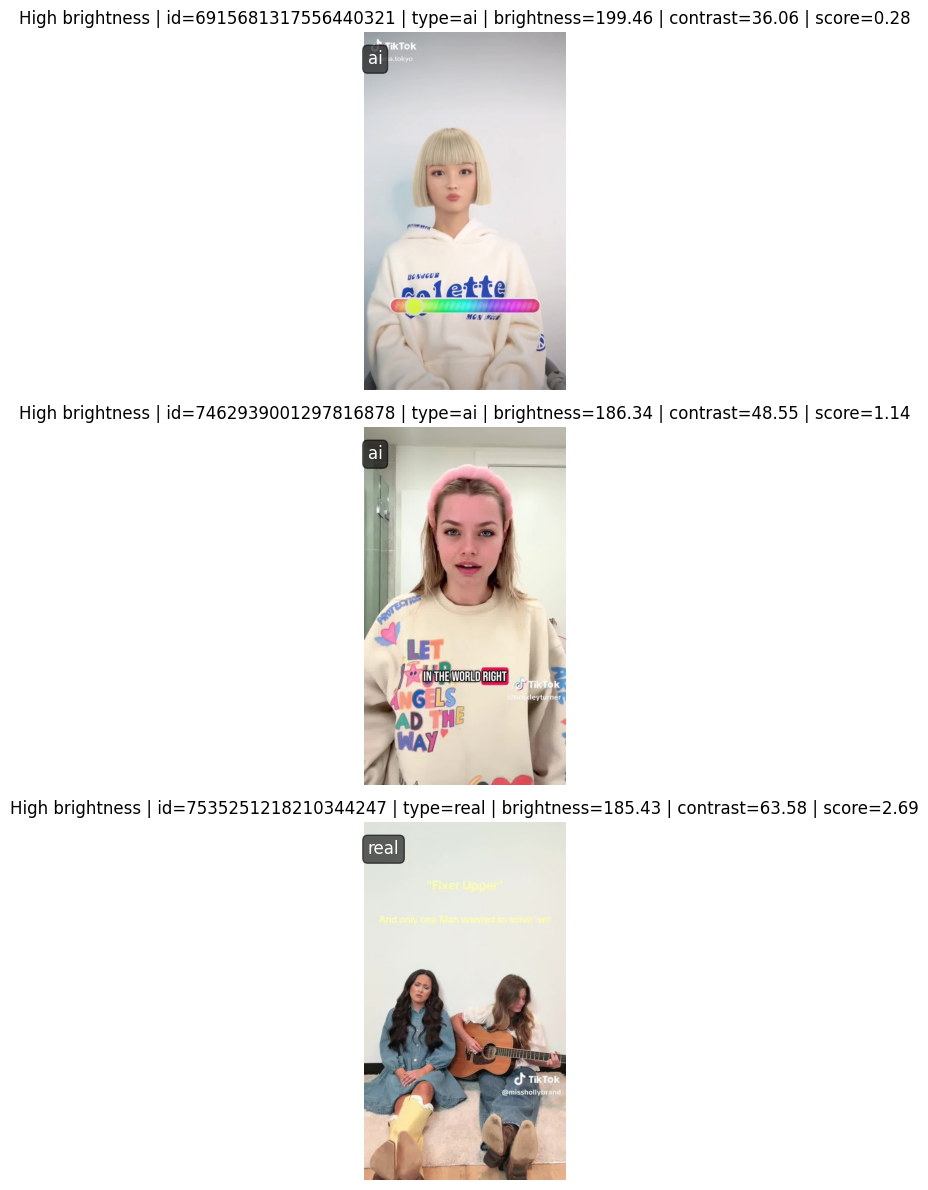

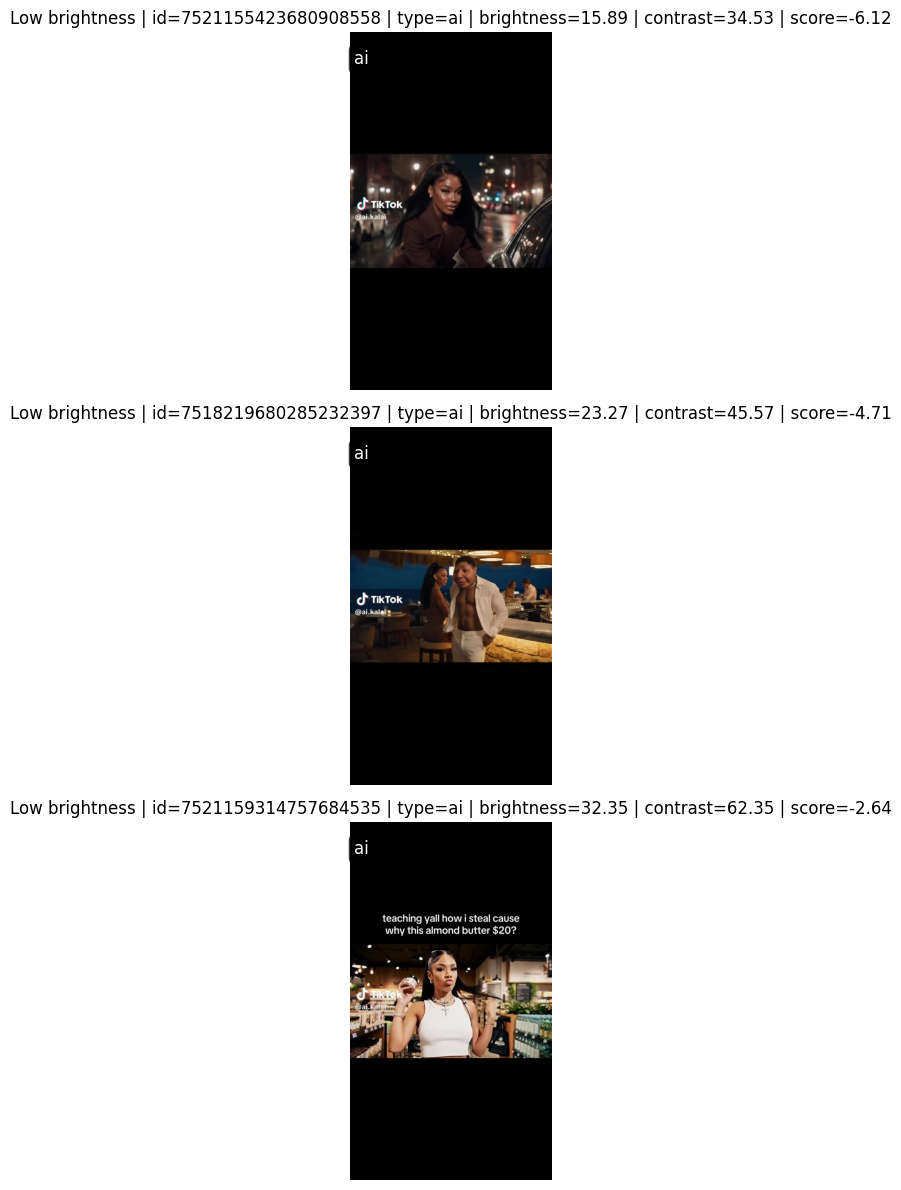

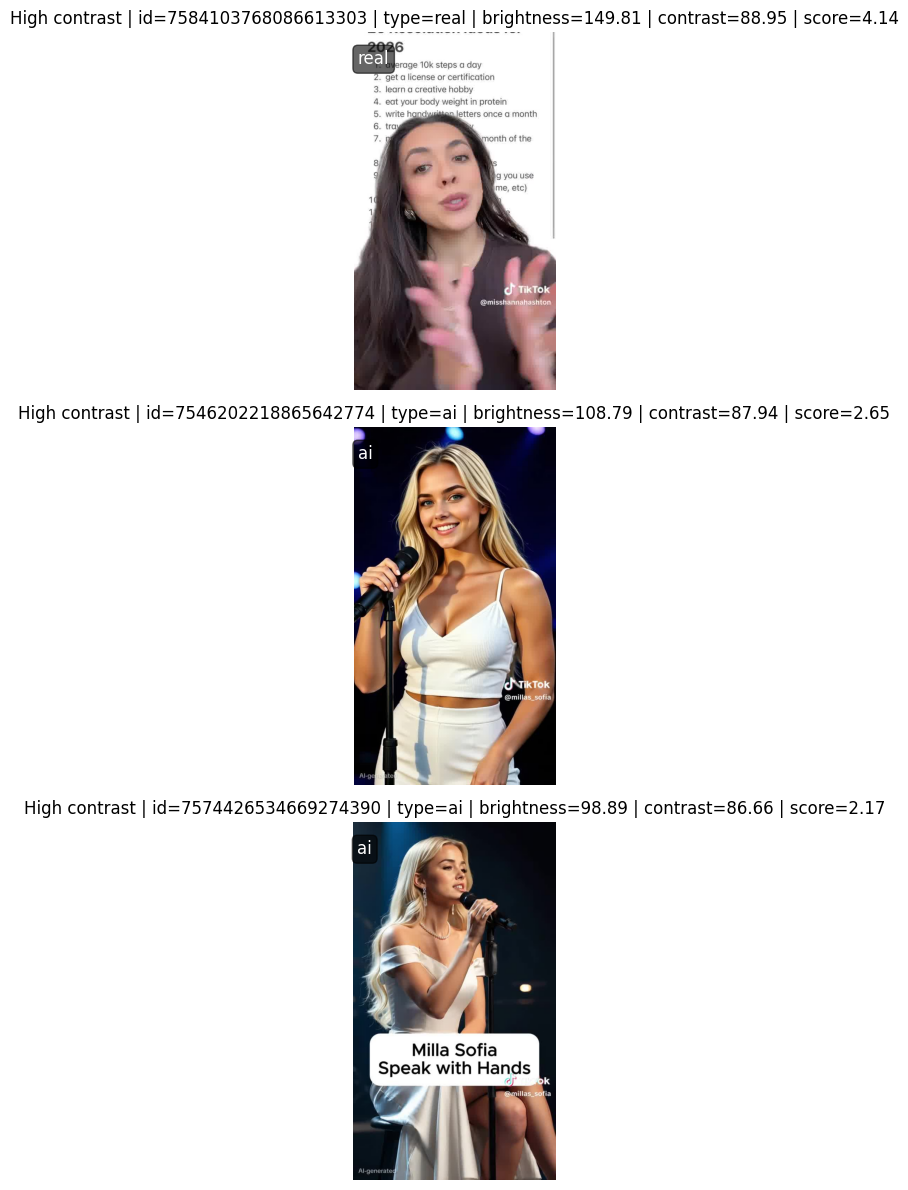

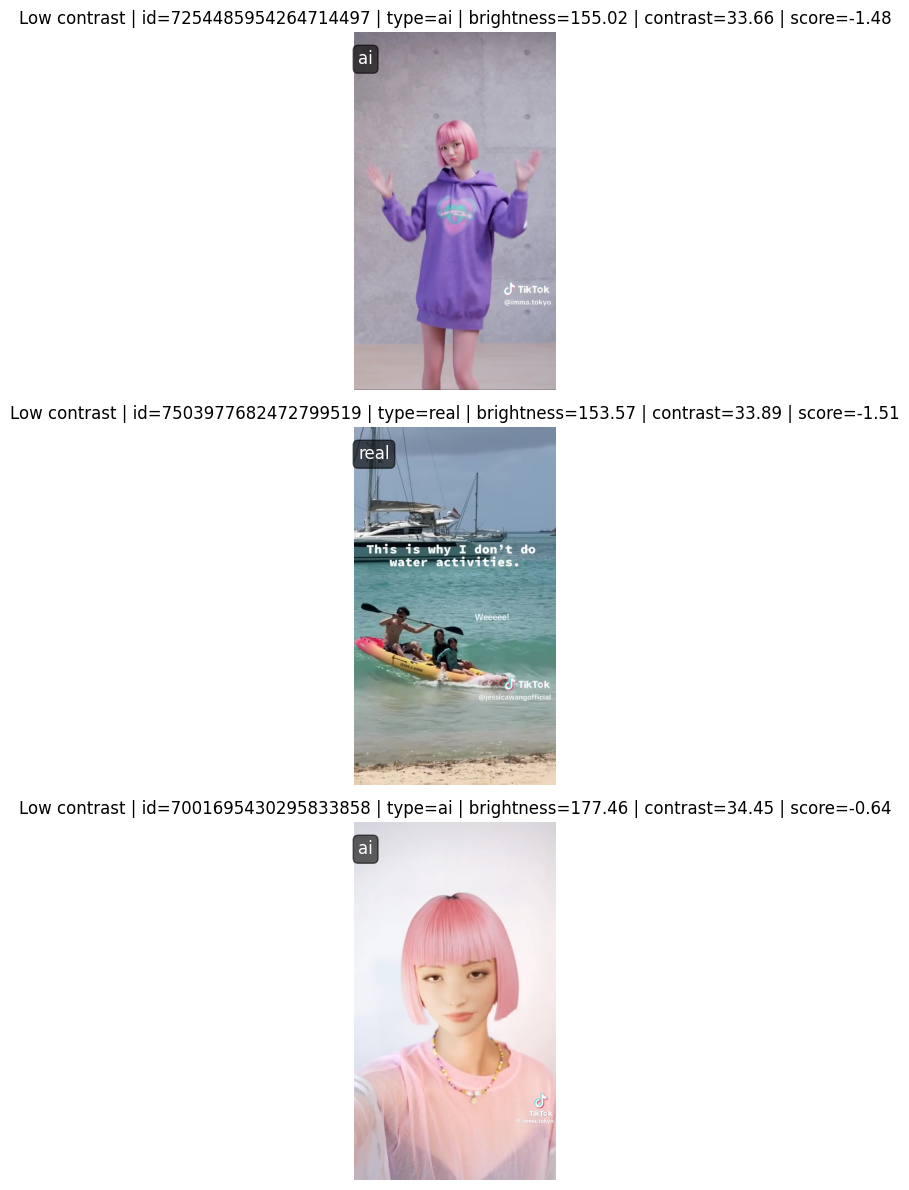

In [ ]:
# Beispiele mit hoher und niedriger Helligkeit sowie hohem und niedrigem Kontrast finden

_df = df.dropna(subset=['brightness_index', 'contrast_index']).copy()

for col in ['brightness_index', 'contrast_index']:
    std = _df[col].std()
    if std == 0 or pd.isna(std):
        _df[col + '_z'] = 0.0
    else:
        _df[col + '_z'] = (_df[col] - _df[col].mean()) / std

_df['bc_score'] = _df['brightness_index_z'] + _df['contrast_index_z']

def pick_examples(df_sorted, n=3):
    rows = []
    for _, row in df_sorted.iterrows():
        vid = get_video_id(row)
        fp = first_frame_path(vid)
        if fp is None:
            continue
        row = row.copy()
        row['frame_path'] = fp
        rows.append(row)
        if len(rows) >= n:
            break
    return rows

def show_examples(rows, title):
    if not rows:
        print(f'No frames found for {title}')
        return
    plt.figure(figsize=(12, 4 * len(rows)))
    for i, row in enumerate(rows, 1):
        img = load_image(row['frame_path'])
        plt.subplot(len(rows), 1, i)
        if img is not None:
            plt.imshow(img)
            plt.axis('off')
        else:
            plt.text(0.5, 0.5, 'Image load failed', ha='center')
            plt.axis('off')
        b = row['brightness_index']
        c = row['contrast_index']
        score = row['bc_score']
        inf = row.get('influencer_type', '')
        vid = get_video_id(row)
        # KI-/Real-Label ins Bild schreiben
        plt.text(0.02, 0.95, f"{inf}", transform=plt.gca().transAxes,
                 ha='left', va='top', fontsize=12, color='white',
                 bbox=dict(boxstyle='round,pad=0.3', fc='black', alpha=0.6))
        plt.title(f"{title} | id={vid} | type={inf} | brightness={b:.2f} | contrast={c:.2f} | score={score:.2f}")
    plt.tight_layout()
    plt.show()

# Beispiele mit hoher und niedriger Helligkeit
high_brightness = pick_examples(_df.sort_values('brightness_index', ascending=False), n=3)
low_brightness = pick_examples(_df.sort_values('brightness_index', ascending=True), n=3)

# Beispiele mit hohem und niedrigem Kontrast
high_contrast = pick_examples(_df.sort_values('contrast_index', ascending=False), n=3)
low_contrast = pick_examples(_df.sort_values('contrast_index', ascending=True), n=3)

# Kombinierte Extrembeispiele
high_examples = pick_examples(_df.sort_values('bc_score', ascending=False), n=3)
low_examples = pick_examples(_df.sort_values('bc_score', ascending=True), n=3)

show_examples(high_brightness, 'High brightness')
show_examples(low_brightness, 'Low brightness')
show_examples(high_contrast, 'High contrast')
show_examples(low_contrast, 'Low contrast')


In [33]:
summary = df.groupby("influencer_type")[["brightness_index", "contrast_index"]].describe().round(2)
display(summary)

brightness_index                                        \
                           count    mean    std    min     25%     50%   
influencer_type                                                          
ai                         250.0  114.91  34.69  15.89   94.60  120.80   
real                       250.0  120.95  22.68  35.87  109.71  122.41   

                                contrast_index                              \
                    75%     max          count   mean    std    min    25%   
influencer_type                                                              
ai               139.30  199.46          250.0  59.56  11.37  33.66  51.78   
real             135.13  185.43          250.0  60.03   7.22  33.89  55.67   

                                      
                   50%    75%    max  
influencer_type                       
ai               59.28  67.10  87.94  
real             60.07  64.22  88.95

/var/folders/xv/tws3wcdj24b6nwt9_f_365jr0000gn/T/ipykernel_21757/1166641993.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


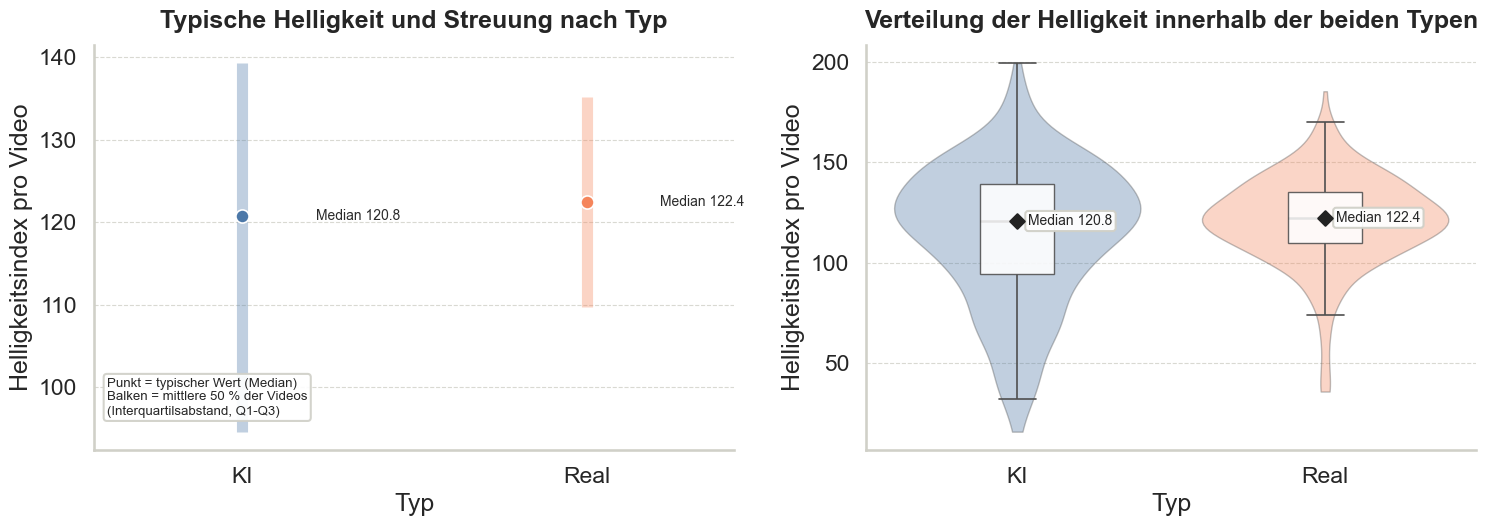

In [ ]:
# Visualisierung der Helligkeit
sns.set_theme(
    style='whitegrid',
    context='talk',
    rc={
        'axes.facecolor': 'white',
        'figure.facecolor': 'white',
        'grid.color': '#d9d9d2',
        'grid.linestyle': '--',
        'grid.linewidth': 0.8,
        'axes.edgecolor': '#d0d0c8',
    },
)

ORDER = ['KI', 'Real']
PALETTE_COLOR = {'KI': '#4C78A8', 'Real': '#F5855B'}

# Deutsche Labels für die Darstellung
df_plot = df.copy()
df_plot['typ'] = df_plot['influencer_type'].map({'ai': 'KI', 'real': 'Real'}).fillna(df_plot['influencer_type'])

fig, axes = plt.subplots(1, 2, figsize=(15.2, 5.6), gridspec_kw={'width_ratios': [1.05, 1]})

# Median und IQR als kompakter Gruppenvergleich
summary = (
    df_plot.groupby('typ')['brightness_index']
    .agg(
        median='median',
        q1=lambda s: s.quantile(0.25),
        q3=lambda s: s.quantile(0.75),
    )
    .reindex(ORDER)
)

x_positions = [0.0, 0.28]

for x, grp in zip(x_positions, ORDER):
    row = summary.loc[grp]
    axes[0].vlines(x=x, ymin=row['q1'], ymax=row['q3'], color=PALETTE_COLOR[grp], linewidth=8, alpha=0.35)
    axes[0].scatter(x, row['median'], s=90, color=PALETTE_COLOR[grp], edgecolor='white', linewidth=1.2, zorder=3)
    axes[0].text(x + 0.06, row['median'], f"Median {row['median']:.1f}", va='center', fontsize=10, color='#2a2a2a')

axes[0].set_title('Typische Helligkeit und Streuung nach Typ', pad=12, weight='semibold')
axes[0].set_xlabel('Typ')
axes[0].set_ylabel('Helligkeitsindex pro Video')
axes[0].set_xticks(x_positions)
axes[0].set_xticklabels(ORDER)
axes[0].set_xlim(-0.12, 0.40)
axes[0].grid(axis='x', visible=False)
axes[0].text(
    0.02, 0.08,
    'Punkt = typischer Wert (Median)\nBalken = mittlere 50 % der Videos\n(Interquartilsabstand, Q1-Q3)',
    transform=axes[0].transAxes,
    ha='left', va='bottom', fontsize=9.5,
    bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='#d0d0c8', alpha=0.92),
)

# Verteilung zusätzlich als Violinplot mit Boxplot
sns.violinplot(
    data=df_plot,
    x='typ',
    y='brightness_index',
    order=ORDER,
    palette=PALETTE_COLOR,
    inner=None,
    cut=0,
    linewidth=1.0,
    alpha=0.35,
    saturation=0.95,
    ax=axes[1],
)

sns.boxplot(
    data=df_plot,
    x='typ',
    y='brightness_index',
    order=ORDER,
    width=0.24,
    fliersize=0,
    boxprops={'facecolor': 'white', 'alpha': 0.88, 'edgecolor': '#4f4f4f', 'zorder': 3},
    whiskerprops={'linewidth': 1.2, 'color': '#4f4f4f'},
    capprops={'linewidth': 1.2, 'color': '#4f4f4f'},
    medianprops={'color': '#222222', 'linewidth': 1.8},
    ax=axes[1],
)

for x, grp in enumerate(ORDER):
    median_val = summary.loc[grp, 'median']
    axes[1].scatter(x, median_val, s=55, color='#222222', marker='D', zorder=4)
    axes[1].annotate(
        f'Median {median_val:.1f}',
        (x, median_val),
        xytext=(8, 0),
        textcoords='offset points',
        va='center',
        fontsize=10,
        bbox=dict(boxstyle='round,pad=0.22', facecolor='white', edgecolor='#d0d0c8', alpha=0.95),
    )

axes[1].set_title('Verteilung der Helligkeit innerhalb der beiden Typen', pad=12, weight='semibold')
axes[1].set_xlabel('Typ')
axes[1].set_ylabel('Helligkeitsindex pro Video')
axes[1].set_xticks(range(len(ORDER)))
axes[1].set_xticklabels(ORDER)
axes[1].grid(axis='x', visible=False)

for ax in axes:
    sns.despine(ax=ax, top=True, right=True)

plt.tight_layout()
plt.show()



/var/folders/xv/tws3wcdj24b6nwt9_f_365jr0000gn/T/ipykernel_21757/2980888122.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


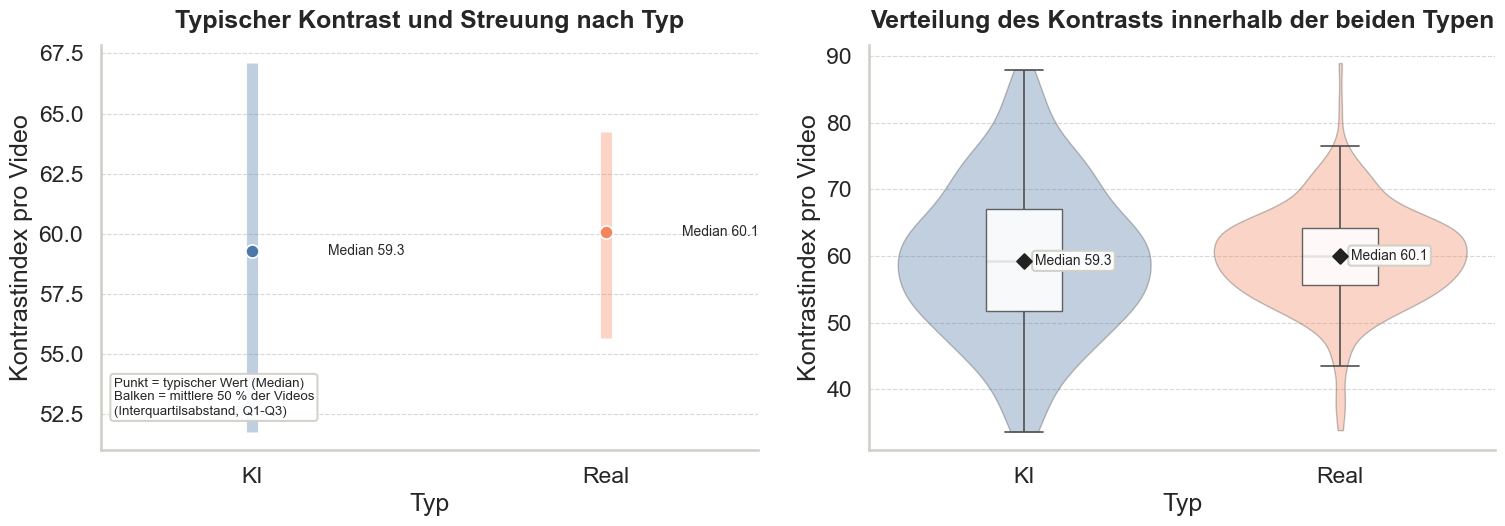

In [35]:
# Visualisierung des Kontrasts
ORDER = ['KI', 'Real']
fig, axes = plt.subplots(1, 2, figsize=(15.2, 5.6), gridspec_kw={'width_ratios': [1.05, 1]})

# Median und IQR als kompakter Gruppenvergleich
summary = (
    df_plot.groupby('typ')['contrast_index']
    .agg(
        median='median',
        q1=lambda s: s.quantile(0.25),
        q3=lambda s: s.quantile(0.75),
    )
    .reindex(ORDER)
)

x_positions = [0.0, 0.28]

for x, grp in zip(x_positions, ORDER):
    row = summary.loc[grp]
    axes[0].vlines(x=x, ymin=row['q1'], ymax=row['q3'], color=PALETTE_COLOR[grp], linewidth=8, alpha=0.35)
    axes[0].scatter(x, row['median'], s=90, color=PALETTE_COLOR[grp], edgecolor='white', linewidth=1.2, zorder=3)
    axes[0].text(x + 0.06, row['median'], f"Median {row['median']:.1f}", va='center', fontsize=10, color='#2a2a2a')

axes[0].set_title('Typischer Kontrast und Streuung nach Typ', pad=12, weight='semibold')
axes[0].set_xlabel('Typ')
axes[0].set_ylabel('Kontrastindex pro Video')
axes[0].set_xticks(x_positions)
axes[0].set_xticklabels(ORDER)
axes[0].set_xlim(-0.12, 0.40)
axes[0].grid(axis='x', visible=False)
axes[0].text(
    0.02, 0.08,
    'Punkt = typischer Wert (Median)\nBalken = mittlere 50 % der Videos\n(Interquartilsabstand, Q1-Q3)',
    transform=axes[0].transAxes,
    ha='left', va='bottom', fontsize=9.5,
    bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='#d0d0c8', alpha=0.92),
)

# Verteilung zusätzlich als Violinplot mit Boxplot
sns.violinplot(
    data=df_plot,
    x='typ',
    y='contrast_index',
    order=ORDER,
    palette=PALETTE_COLOR,
    inner=None,
    cut=0,
    linewidth=1.0,
    alpha=0.35,
    saturation=0.95,
    ax=axes[1],
)

sns.boxplot(
    data=df_plot,
    x='typ',
    y='contrast_index',
    order=ORDER,
    width=0.24,
    fliersize=0,
    boxprops={'facecolor': 'white', 'alpha': 0.88, 'edgecolor': '#4f4f4f', 'zorder': 3},
    whiskerprops={'linewidth': 1.2, 'color': '#4f4f4f'},
    capprops={'linewidth': 1.2, 'color': '#4f4f4f'},
    medianprops={'color': '#222222', 'linewidth': 1.8},
    ax=axes[1],
)

for x, grp in enumerate(ORDER):
    median_val = summary.loc[grp, 'median']
    axes[1].scatter(x, median_val, s=55, color='#222222', marker='D', zorder=4)
    axes[1].annotate(
        f'Median {median_val:.1f}',
        (x, median_val),
        xytext=(8, 0),
        textcoords='offset points',
        va='center',
        fontsize=10,
        bbox=dict(boxstyle='round,pad=0.22', facecolor='white', edgecolor='#d0d0c8', alpha=0.95),
    )

axes[1].set_title('Verteilung des Kontrasts innerhalb der beiden Typen', pad=12, weight='semibold')
axes[1].set_xlabel('Typ')
axes[1].set_ylabel('Kontrastindex pro Video')
axes[1].set_xticks(range(len(ORDER)))
axes[1].set_xticklabels(ORDER)
axes[1].grid(axis='x', visible=False)

for ax in axes:
    sns.despine(ax=ax, top=True, right=True)

plt.tight_layout()
plt.show()



In [39]:
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return float('nan')
    dof = nx + ny - 2
    pooled = np.sqrt(((nx - 1) * np.std(x, ddof=1) ** 2 + (ny - 1) * np.std(y, ddof=1) ** 2) / dof)
    if pooled == 0 or np.isnan(pooled):
        return float('nan')
    return (np.mean(x) - np.mean(y)) / pooled

results = []
for metric in ['brightness_index', 'contrast_index']:
    ai_vals = df[df['influencer_type'] == 'ai'][metric].dropna()
    real_vals = df[df['influencer_type'] == 'real'][metric].dropna()
    if len(ai_vals) == 0 or len(real_vals) == 0:
        continue
    t_stat, t_p = ttest_ind(ai_vals, real_vals, equal_var=False)
    u_stat, u_p = mannwhitneyu(ai_vals, real_vals, alternative='two-sided')
    d = cohens_d(ai_vals, real_vals)
    results.append({
        'metric': metric,
        't_p': t_p,
        'u_p': u_p,
        'cohens_d': d,
        'mean_ai': ai_vals.mean(),
        'mean_real': real_vals.mean(),
    })
results_df = pd.DataFrame(results)
display(results_df.round(4))


,metric,t_p,u_p,cohens_d,mean_ai,mean_real
0,brightness_index,0.0217,0.2374,-0.2062,114.9075,120.9493
1,contrast_index,0.5814,0.3924,-0.0494,59.5563,60.0266


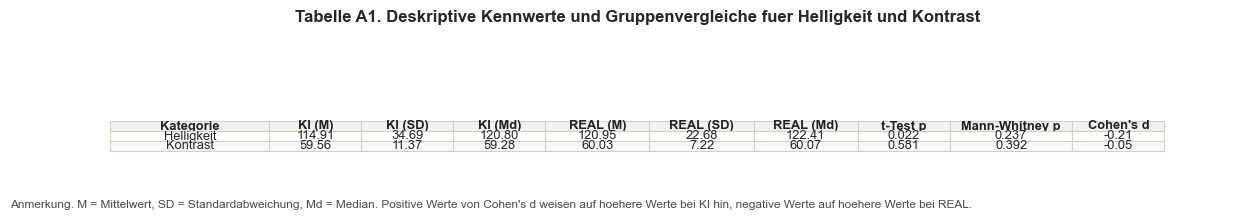

In [41]:
# Tabelle A1 als einbindbare Abbildung
label_map = {
    'brightness_index': 'Helligkeit',
    'contrast_index': 'Kontrast',
}

table_rows = []
for metric in ['brightness_index', 'contrast_index']:
    ai_vals = df.loc[df['influencer_type'] == 'ai', metric].dropna()
    real_vals = df.loc[df['influencer_type'] == 'real', metric].dropna()
    result_row = results_df.loc[results_df['metric'] == metric].iloc[0]

    table_rows.append({
        'Kategorie': label_map[metric],
        'KI (M ± SD)': f"{ai_vals.mean():.2f} ± {ai_vals.std(ddof=1):.2f}",
        'REAL (M ± SD)': f"{real_vals.mean():.2f} ± {real_vals.std(ddof=1):.2f}",
        'KI (Md)': f"{ai_vals.median():.2f}",
        'REAL (Md)': f"{real_vals.median():.2f}",
        'p (t)': f"{result_row['t_p']:.3f}",
        'p (U)': f"{result_row['u_p']:.3f}",
        "d": f"{result_row['cohens_d']:.2f}",
    })

table_plot_df = pd.DataFrame(table_rows)
fig, ax = plt.subplots(figsize=(11.6, 2.1))
ax.axis('off')

col_widths = [0.14, 0.19, 0.19, 0.10, 0.10, 0.08, 0.08, 0.06]
table = ax.table(
    cellText=table_plot_df.values,
    colLabels=table_plot_df.columns,
    cellLoc='center',
    colLoc='center',
    colWidths=col_widths,
    loc='center',
)

table.auto_set_font_size(False)
table.set_fontsize(9.4)
table.scale(1, 1.42)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#d0d0c8')
    cell.set_linewidth(0.8)
    if row == 0:
        cell.set_facecolor('#f3f1eb')
        cell.set_text_props(weight='semibold', color='#222222')
    else:
        cell.set_facecolor('white' if row % 2 == 1 else '#faf9f6')

fig.suptitle(
    'Tabelle A1. Deskriptive Kennwerte und Gruppenvergleiche für Helligkeit und Kontrast',
    x=0.5,
    y=0.98,
    fontsize=12.2,
    fontweight='semibold',
)
fig.text(
    0.01,
    0.06,
    "Anmerkung. M = Mittelwert, SD = Standardabweichung, Md = Median, p (t) = p-Wert des t-Tests, p (U) = p-Wert des Mann-Whitney-U-Tests. Negative d-Werte weisen auf höhere Werte bei REAL hin.",
    fontsize=8.6,
    color='#4a4a4a',
    ha='left',
)
plt.tight_layout(rect=[0, 0.1, 1, 0.88])
plt.show()


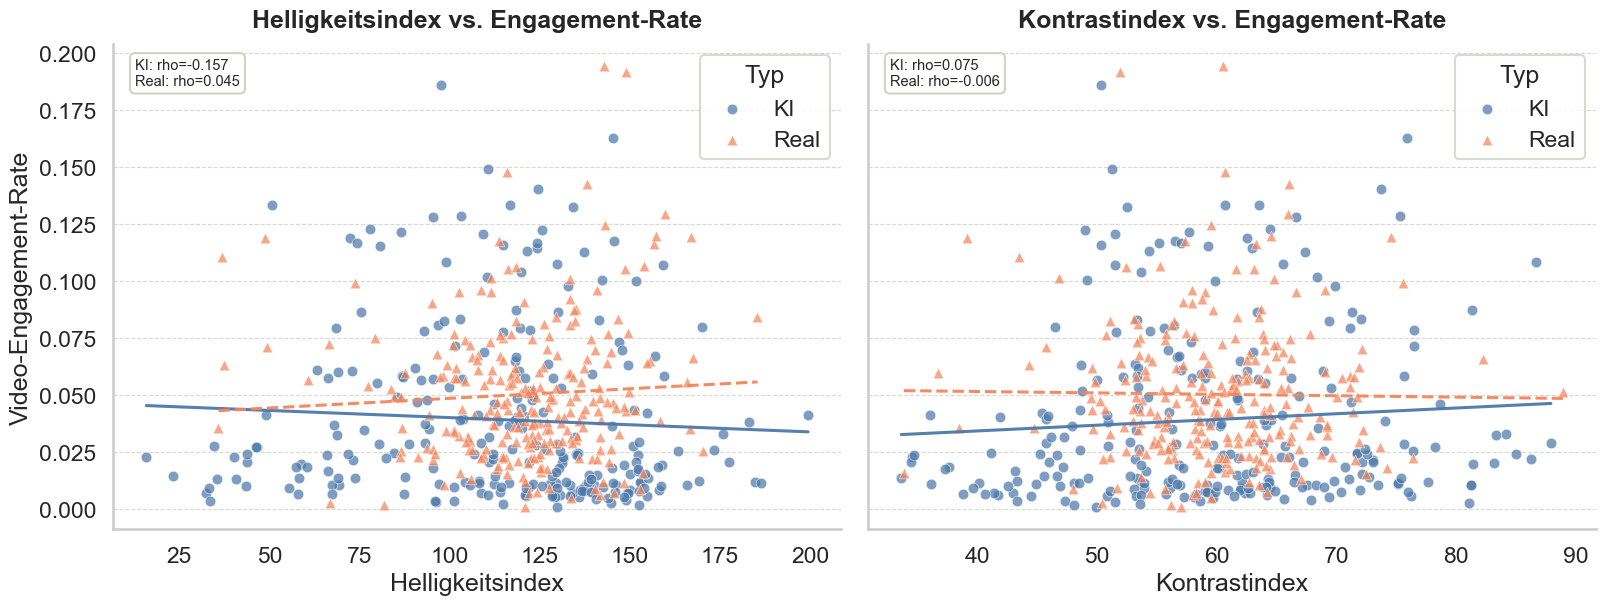

,Metrik,Spearman_rho,p_Wert
0,Helligkeitsindex,-0.0665,0.1374
1,Kontrastindex,0.0443,0.3228


In [37]:
# Korrelationsplots mit deutschen Labels
sns.set_theme(
    style='whitegrid',
    context='talk',
    rc={
        'axes.facecolor': 'white',
        'figure.facecolor': 'white',
        'grid.color': '#d9d9d2',
        'grid.linestyle': '--',
        'grid.linewidth': 0.8,
    },
)

# Deutsche Labels und konsistente Farben
df_plot = df.copy()
df_plot['typ'] = df_plot['influencer_type'].map({'ai': 'KI', 'real': 'Real'}).fillna(df_plot['influencer_type'])
ORDER = ['KI', 'Real']
PALETTE_COLOR = {'KI': '#4C78A8', 'Real': '#F5855B'}
MARKER = {'KI': 'o', 'Real': '^'}
LINESTYLE = {'KI': '-', 'Real': '--'}

korrelations_ergebnisse = []
metriken = [
    ('brightness_index', 'Helligkeitsindex'),
    ('contrast_index', 'Kontrastindex'),
]

fig, axes = plt.subplots(1, 2, figsize=(16.4, 6.4), sharey=True)

for ax, (metric_col, metric_label) in zip(axes, metriken):
    rho, pval = spearmanr(df_plot[metric_col], df_plot['video_engagement_rate'], nan_policy='omit')
    korrelations_ergebnisse.append({'Metrik': metric_label, 'Spearman_rho': rho, 'p_Wert': pval})
    stats_lines = []

    for grp in ORDER:
        sub = df_plot[df_plot['typ'] == grp]
        grp_rho, grp_pval = spearmanr(sub[metric_col], sub['video_engagement_rate'], nan_policy='omit')
        stats_lines.append(f'{grp}: rho={grp_rho:.3f}')

        sns.scatterplot(
            data=sub,
            x=metric_col,
            y='video_engagement_rate',
            color=PALETTE_COLOR[grp],
            marker=MARKER[grp],
            edgecolor='white',
            linewidth=0.5,
            s=58,
            alpha=0.72,
            ax=ax,
            label=grp,
        )

        sns.regplot(
            data=sub,
            x=metric_col,
            y='video_engagement_rate',
            scatter=False,
            ci=None,
            color=PALETTE_COLOR[grp],
            line_kws={'linewidth': 2.2, 'alpha': 0.95, 'linestyle': LINESTYLE[grp]},
            ax=ax,
        )

    ax.set_title(f'{metric_label} vs. Engagement-Rate', pad=12, weight='semibold')
    ax.set_xlabel(metric_label)
    ax.set_ylabel('Video-Engagement-Rate')
    ax.grid(axis='x', visible=False)

    ax.text(
        0.03, 0.97,
        '\n'.join(stats_lines),
        transform=ax.transAxes,
        ha='left', va='top',
        fontsize=10.5,
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#d0d0c8', alpha=0.96),
    )

    sns.despine(ax=ax, top=True, right=True)

handles, labels = axes[0].get_legend_handles_labels()
legend_handles = handles[:2]
legend_labels = labels[:2]
for ax in axes:
    ax.legend(legend_handles, legend_labels, title='Typ', loc='best', frameon=True, facecolor='white', edgecolor='#d0d0c8')

plt.tight_layout()
plt.show()

korrelations_df = pd.DataFrame(korrelations_ergebnisse).round(4)
display(korrelations_df)



In [38]:
print('Kurzinterpretation:')

def sig_label(p):
    return 'signifikant' if pd.notna(p) and p < 0.05 else 'nicht signifikant'

# Gruppenunterschiede
if 'results_df' in globals() and not results_df.empty:
    for _, row in results_df.iterrows():
        metric = row['metric']
        mean_diff = row['mean_ai'] - row['mean_real']
        direction = 'hoeher bei KI' if mean_diff > 0 else ('hoeher bei Real' if mean_diff < 0 else 'kein Mittelwertunterschied')

        if metric == 'brightness_index':
            print(f"- Beleuchtung ({metric}): t-Test ist {sig_label(row['t_p'])} (p={row['t_p']:.4f}), Mann-Whitney ist {sig_label(row['u_p'])} (p={row['u_p']:.4f}). Interpretation: Mittelwert/Median zeigen, welche Gruppe heller ist ({direction}).")
        elif metric == 'contrast_index':
            print(f"- Kontrast ({metric}): t-Test ist {sig_label(row['t_p'])} (p={row['t_p']:.4f}), Mann-Whitney ist {sig_label(row['u_p'])} (p={row['u_p']:.4f}). Interpretation: Unterschied in der Farb-/Helligkeitsabstufung zwischen KI und Real ({direction}).")
else:
    print('- Keine ausreichenden Daten für Gruppenvergleich vorhanden.')

# Engagement-Zusammenhang
if 'korrelations_df' in globals() and not korrelations_df.empty:
    for _, row in korrelations_df.iterrows():
        rho = row['Spearman_rho']
        p = row['p_Wert']
        metric = row['Metrik']
        direction = 'positiv' if rho > 0 else ('negativ' if rho < 0 else 'neutral')
        print(f"- Engagement ({metric}): Spearman ist {sig_label(p)} (rho={rho:.3f}, p={p:.4f}). Interpretation: {direction}er Zusammenhang zwischen Metrik und Engagement.")


Kurzinterpretation:
- Beleuchtung (brightness_index): t-Test ist signifikant (p=0.0217), Mann-Whitney ist nicht signifikant (p=0.2374). Interpretation: Mittelwert/Median zeigen, welche Gruppe heller ist (höher bei Real).
- Kontrast (contrast_index): t-Test ist nicht signifikant (p=0.5814), Mann-Whitney ist nicht signifikant (p=0.3924). Interpretation: Unterschied in der Farb-/Helligkeitsabstufung zwischen KI und Real (höher bei Real).
- Engagement (Helligkeitsindex): Spearman ist nicht signifikant (rho=-0.067, p=0.1374). Interpretation: negativer Zusammenhang zwischen Metrik und Engagement.
- Engagement (Kontrastindex): Spearman ist nicht signifikant (rho=0.044, p=0.3228). Interpretation: positiver Zusammenhang zwischen Metrik und Engagement.
